In [16]:
from sklearn.datasets import load_iris

iris = load_iris()

data = iris.data
target = iris.target

data = data[target !=0, :2]
target = target[target !=0]

from sklearn.model_selection import train_test_split

train_data, test_data, train_target, test_target = train_test_split(
    data, target, train_size=0.9, random_state=2021
)

iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [18]:
#선형 커널
from sklearn.svm import SVC

linear_svc = SVC(kernel="linear")
linear_svc.fit(train_data, train_target)

SVC(kernel='linear')

[-2.27323747 -2.27322656 -2.27321566 ...  3.18149927  3.18151018
  3.18152109]


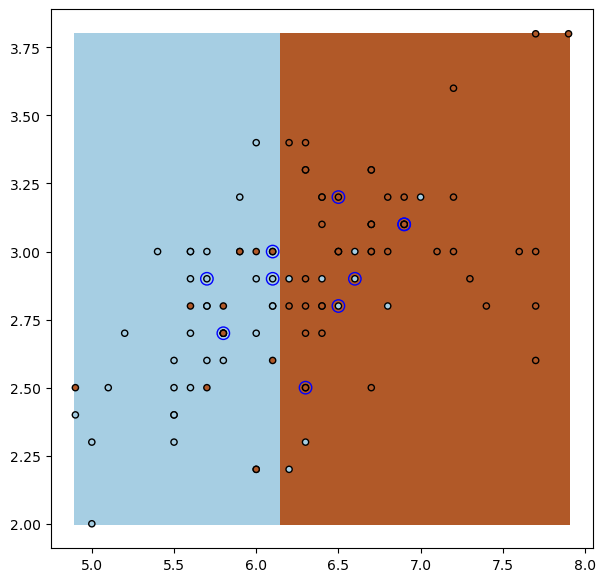

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def plot_support_vector_machine(svm):
    # 전체 데이터
    plt.scatter(data[:, 0], data[:, 1], c=target, zorder=10, cmap=plt.cm.Paired,
                edgecolor='k', s=20)  ##'sepal length (cm)', 'sepal width (cm)',
    # test 데이터
    plt.scatter(test_data[:, 0], test_data[:, 1], s=80, facecolors='none',
                zorder=10, edgecolor='b')

    plt.axis('tight')  #그래프의 간격을 tight로 조정
    x_min = data[:, 0].min()
    x_max = data[:, 0].max()
    y_min = data[:, 1].min()
    y_max = data[:, 1].max()
    
    # 영역 칠하기
    XX, YY = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]  #2차원 그리드를 생성
    #print("XX:", XX)
    #print("XX.ravel()", XX.ravel())
    #print("YY:",YY)

    # svm.decision_function : 정 경계에서 얼마나 가까운지. 경계에서 가까울수록 확신이 떨어짐.
    #Z= 일반적으로 분류 결정 경계로부터의 거리나 유사도
    Z = svm.decision_function(np.c_[XX.ravel(), YY.ravel()])  #열단위로 결합해서 2차원 배열을 만든후, svm.decision_function 적용 
    print(Z)
    Z = Z.reshape(XX.shape)
    plt.pcolormesh(XX, YY, Z > 0, cmap=plt.cm.Paired, shading="auto")  #cmap = color map , pcolormesh : color graph
    #plt.contour(XX, YY, Z, colors=['k', 'k', 'k'],
    #            linestyles=['--', '-', '--'], levels=[-.5, 0, .5])  # contour(컨투어) : 등고선


plt.figure(figsize=(7,7))
plot_support_vector_machine(linear_svc)

[-2.27323747 -2.27322656 -2.27321566 ...  3.18149927  3.18151018
  3.18152109]


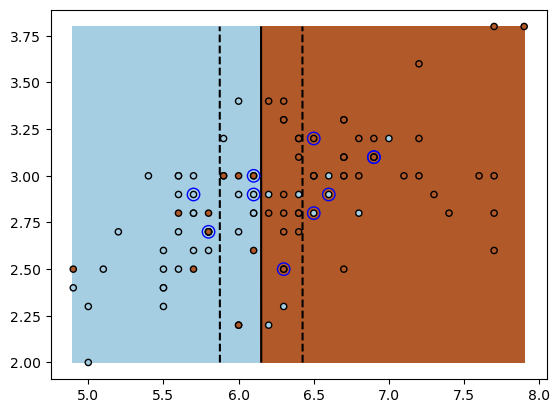

In [48]:
def plot_support_vector_machine2(svm):
    plt.scatter(data[:,0], data[:,1], c=target, zorder=10, cmap=plt.cm.Paired, edgecolor='k', s=20)
    plt.scatter(test_data[:, 0], test_data[:, 1], s=80, facecolors='none', zorder=10, edgecolor='b')

    plt.axis('tight')  #그래프의 간격을 tight로 조정
    x_min = data[:, 0].min()
    x_max = data[:, 0].max()
    y_min = data[:, 1].min()
    y_max = data[:, 1].max()

    XX, YY = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
    #print("XX:", XX)
    #print("XX.ravel()", XX.ravel())
    #print("YY:",YY)

    Z = svm.decision_function(np.c_[XX.ravel(), YY.ravel()])  #열단위로 결합해서 2차원 배열을 만든후, svm.decision_function 적용 
    print(Z)
    Z = Z.reshape(XX.shape)
    plt.pcolormesh(XX, YY, Z > 0, cmap=plt.cm.Paired, shading="auto")

    plt.contour(XX, YY, Z, colors=['k', 'k', 'k'],
                linestyles=['--', '-', '--'], levels=[-.5, 0, .5])  # contour(컨투어) : 등고선

    
plot_support_vector_machine2(linear_svc)

[-1.93986017 -1.93958612 -1.93933287 ...  4.11566244  4.11424588
  4.11279336]


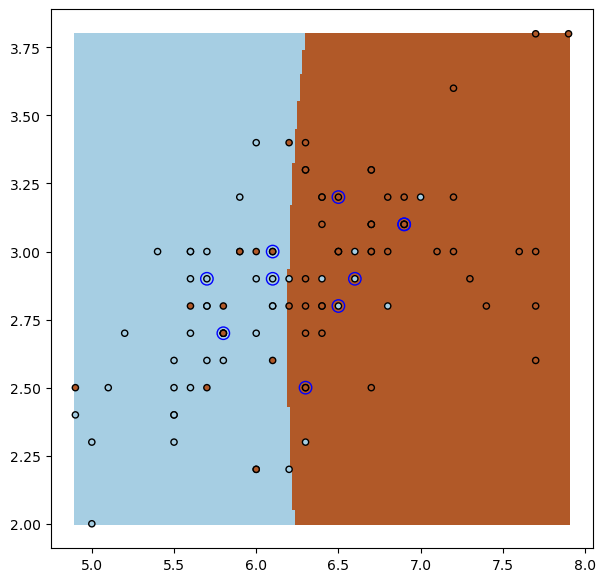

In [50]:
poly_svc = SVC(kernel="poly")

poly_svc.fit(train_data, train_target)
plt.figure(figsize=(7,7))
plot_support_vector_machine(poly_svc)

[-2.24353037 -2.23348232 -2.22376178 ...  3.65359232  3.64970872
  3.64549761]


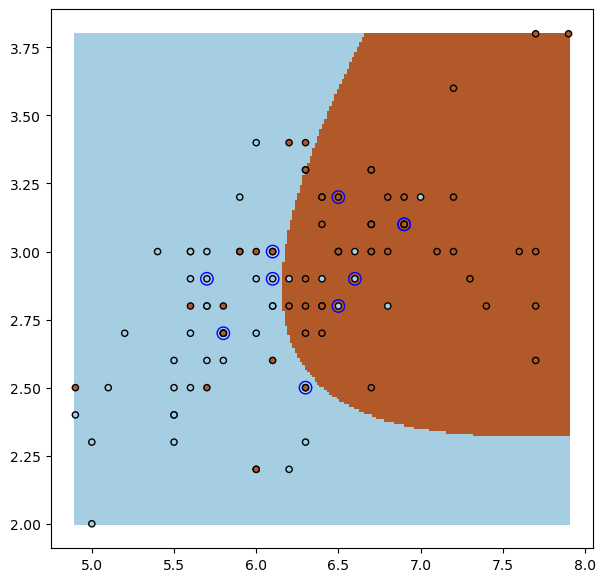

In [64]:
poly_svc = SVC(kernel="poly", gamma=10, degree=2)
poly_svc.fit(train_data, train_target)

plt.figure(figsize=(7,7))
plot_support_vector_machine(poly_svc)